<a href="https://colab.research.google.com/github/felipealencar/courses/blob/artificial-intelligence/artificial-intelligence/lec-08/time_series_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 08 — Time-series forecasting with a neural network

**Course:** Artificial Intelligence · prof. Felipe Alencar · IFAL — Arapiraca

## Learning objectives
1. Turn a **time series** into a supervised learning problem with **lag features**.
2. Respect the arrow of time: use a **chronological** train/test split (never
   shuffle a forecast!).
3. Compare a neural network (**`MLPRegressor`**) against a **persistence
   baseline**.
4. Evaluate forecasts with **MAE** and **RMSE** and read the residuals.

## The task
Forecast **tomorrow's mean temperature** in Maceió/AL from the last few days of
weather ([dataset card](../../datasets/maceio_daily_weather.DATASET.md)).

In [1]:
import os
import pandas as pd

# Make plots show up inline and look consistent across the course.
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5)

RAW_BASE = ("https://raw.githubusercontent.com/felipealencar/courses/"
            "artificial-intelligence/datasets/")

def load_dataset(name):
    """Load a course dataset by file name from the local catalog or GitHub."""
    here = os.getcwd()
    for _ in range(6):
        local = os.path.join(here, "datasets", name)
        if os.path.exists(local):
            return pd.read_csv(local)
        here = os.path.dirname(here)
    return pd.read_csv(RAW_BASE + name)  # Colab / standalone fallback


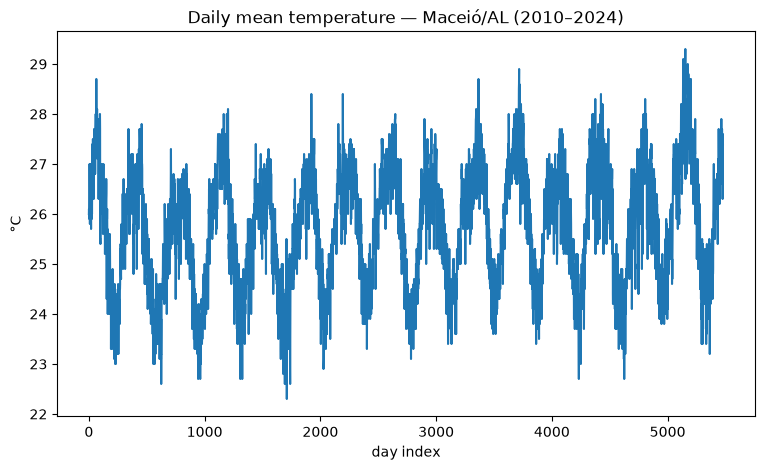

In [2]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

wx = load_dataset("maceio_daily_weather.csv").sort_values("date").reset_index(drop=True)
series = wx["temp_mean_c"]
ax = series.plot()
ax.set_title("Daily mean temperature — Maceió/AL (2010–2024)")
ax.set_xlabel("day index"); ax.set_ylabel("°C"); plt.show()

## 1. Build lag features

To predict day *t* we use the temperatures of days *t-1 … t-N*. We also add the
**month** to let the model learn seasonality.

In [3]:
N_LAGS = 7
df = wx[["temp_mean_c", "month"]].copy()
for k in range(1, N_LAGS + 1):
    df[f"lag_{k}"] = df["temp_mean_c"].shift(k)
df = df.dropna().reset_index(drop=True)

feature_cols = [f"lag_{k}" for k in range(1, N_LAGS + 1)] + ["month"]
X = df[feature_cols].values
y = df["temp_mean_c"].values
print("samples:", X.shape, "features:", feature_cols)

samples: (5472, 8) features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'month']


## 2. Chronological split

We train on the earlier portion and test on the **later** portion — exactly how a
real forecast is used. Shuffling here would leak the future into training.

In [4]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"train days: {len(X_train)}   test days: {len(X_test)}")

train days: 4377   test days: 1095


## 3. Baseline: persistence ("tomorrow = today")

The simplest forecast is *the temperature won't change*. Any model must beat it.

In [5]:
# lag_1 is yesterday's temperature == naive prediction of today
naive_pred = df["lag_1"].values[split:]
mae_naive = mean_absolute_error(y_test, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(y_test, naive_pred))
print(f"persistence baseline:  MAE = {mae_naive:.3f} °C   RMSE = {rmse_naive:.3f} °C")

persistence baseline:  MAE = 0.451 °C   RMSE = 0.589 °C


## 4. Neural network (multi-layer perceptron)

An `MLPRegressor` with two hidden layers. We scale inputs first — neural nets
train far better on standardized features.

In [6]:
mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(32, 16), activation="relu",
                 max_iter=600, random_state=0),
)
mlp.fit(X_train, y_train)
pred = mlp.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"MLP forecast:          MAE = {mae:.3f} °C   RMSE = {rmse:.3f} °C")
print(f"improvement over baseline: {100*(mae_naive-mae)/mae_naive:.1f}% lower MAE")

MLP forecast:          MAE = 0.427 °C   RMSE = 0.543 °C
improvement over baseline: 5.2% lower MAE


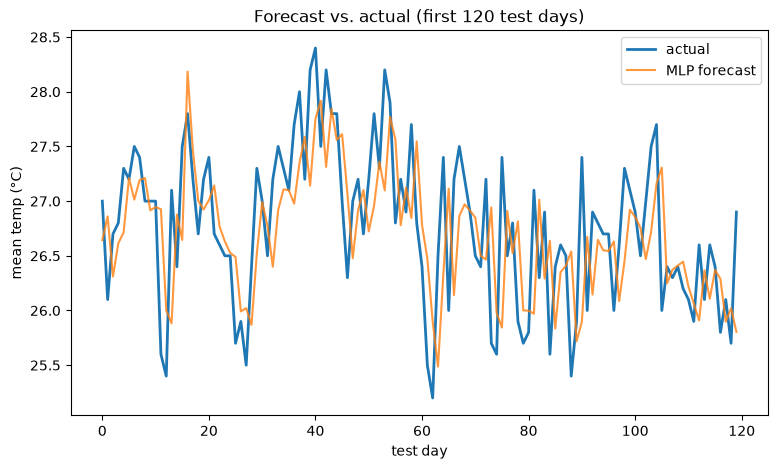

In [7]:
plt.plot(y_test[:120], label="actual", linewidth=2)
plt.plot(pred[:120], label="MLP forecast", alpha=0.8)
plt.title("Forecast vs. actual (first 120 test days)")
plt.xlabel("test day"); plt.ylabel("mean temp (°C)"); plt.legend(); plt.show()

### 5. Residuals

Good forecasts leave residuals that look like noise centered on zero.

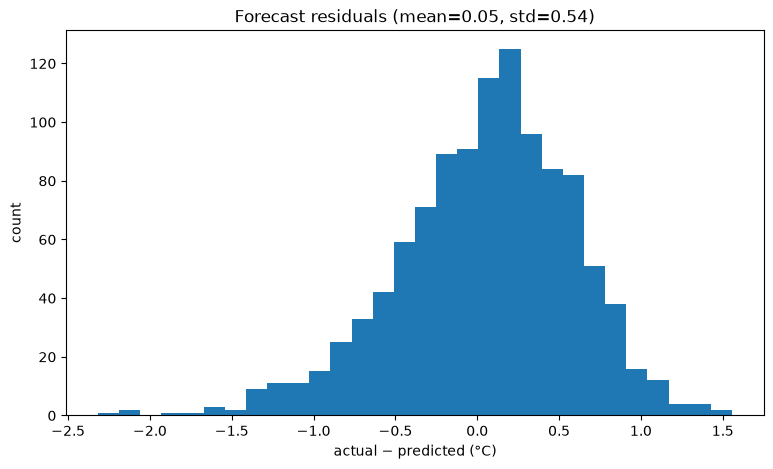

In [8]:
resid = y_test - pred
plt.hist(resid, bins=30)
plt.title(f"Forecast residuals (mean={resid.mean():.2f}, std={resid.std():.2f})")
plt.xlabel("actual − predicted (°C)"); plt.ylabel("count"); plt.show()

## What did we learn?
- A time series becomes a normal supervised dataset once you add **lag features**.
- **Never shuffle** a forecasting split — evaluation must mimic predicting the
  future from the past.
- Always compare against a **naive baseline**; a fancy model that can't beat
  "tomorrow = today" is not worth its complexity.
- A small **MLP** captures short-term dynamics and seasonality from just a week of
  history — on a CPU, in seconds.

### Exercises
1. Try `N_LAGS` of 1, 3, 14, 30. Plot test MAE vs. number of lags. Do more lags
   always help?
2. Add `humidity_pct` and `pressure_hpa` lags as extra features. Does multivariate
   input beat temperature-only?
3. Forecast `temp_max_c` instead of the mean. Is it harder or easier? Why?
4. **Discuss:** the persistence baseline is strong because daily temperature is
   *autocorrelated*. Name another quantity in the dataset where persistence would
   be a **weak** baseline, and explain why.